In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# Check bounce rate value if no pages were visited
# Are there sessions where no pages were visited?

df_check = df[df['Administrative'] + df['Informational'] + df['ProductRelated'] == 0]
df_check

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
2683,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,May,3,2,3,18,Returning_Visitor,True,False
3187,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,May,2,2,8,3,Returning_Visitor,False,False
5557,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,9,3,Returning_Visitor,False,False
5800,0,0.0,0,0.0,0,0.0,0.18,0.181818,0.0,0.0,June,2,2,7,6,Returning_Visitor,False,False
8052,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,9,2,Returning_Visitor,False,False
11865,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,8,8,Returning_Visitor,False,False


In [26]:
df_check.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,6.0,6.0,6.0,6.0,6.0,6.0,6.000000,6.000000,6.0,6.0,6.000000,6.000000,6.000000,6.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.196667,0.196970,0.0,0.0,1.666667,1.500000,7.333333,6.666667
std,0.0,0.0,0.0,0.0,0.0,0.0,0.008165,0.007423,0.0,0.0,0.816497,0.547723,2.250926,5.988879
min,0.0,0.0,0.0,0.0,0.0,0.0,0.180000,0.181818,0.0,0.0,1.000000,1.000000,3.000000,2.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,1.000000,1.000000,7.250000,3.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,1.500000,1.500000,8.000000,4.500000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,2.000000,2.000000,8.750000,7.500000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,3.000000,2.000000,9.000000,18.000000


In [ ]:
df_check.shape

(6, 18)

There are only 6 rows where the 3 different pages have combined visits of 0. For those pages the mean bounce and exit rates are ~0.19, and the median is 0.20 for both.

In [5]:
# VisitorType is a string
df['VisitorType'].unique()

<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

In [6]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [7]:
pct = df[df['Revenue'] == True]['VisitorType'].value_counts(normalize=True) * 100
print(pct)

VisitorType
Returning_Visitor    77.044025
New_Visitor          22.117400
Other                 0.838574
Name: proportion, dtype: float64


Out of all sessions for which a purchase was made, the type of visitor a returning customer. 

Make a feature 'is_returning_visitor'

In [8]:
df.shape

(12330, 18)

In [9]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [10]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


For page durations - units (seconds vs minutes) were not specified in the metadata. An intuitive guess would be that the duration is represented in seconds, as half of the sessions included a duration of 598 for a product related page, which, if representing seconds, is 10 minutes- and for 75% of product page visits- ~1464 seconds (~24 minutes) or less per session. However whether duration for pages is indeed in seconds cannot be concretely confirmed at this time.

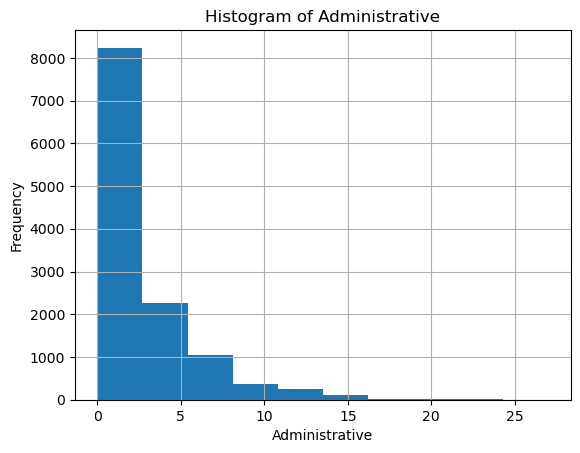

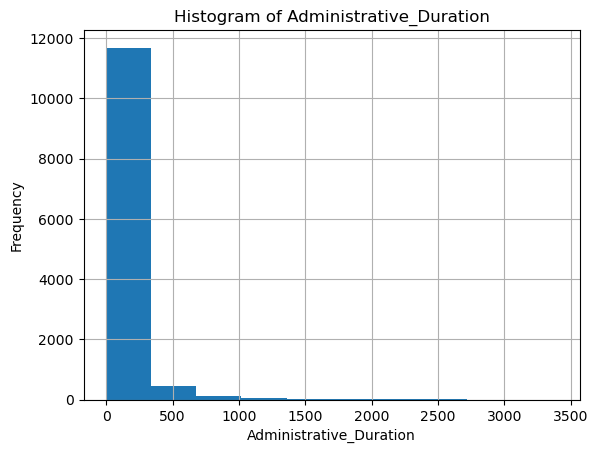

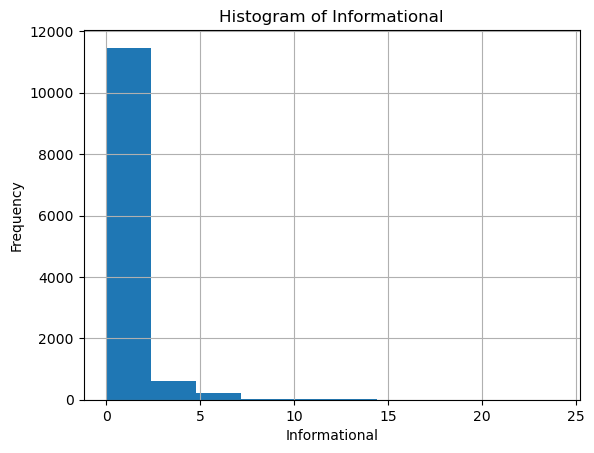

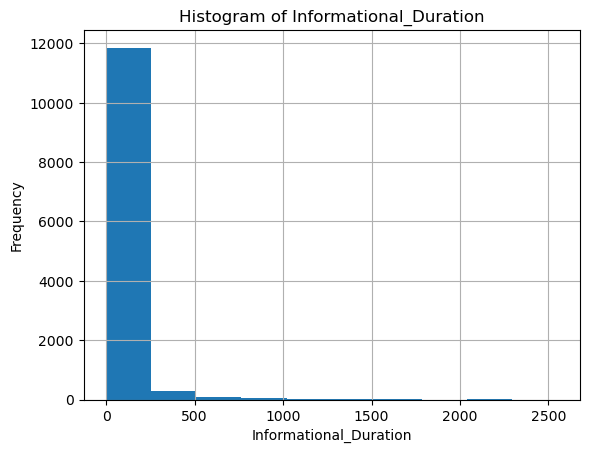

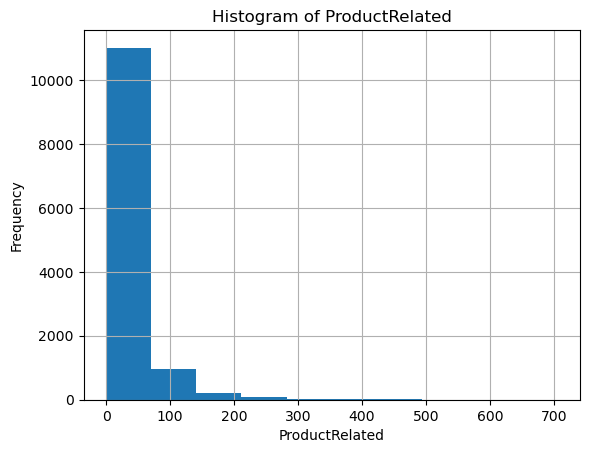

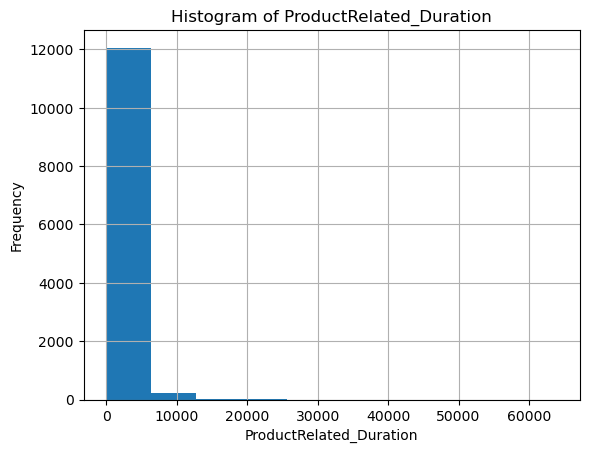

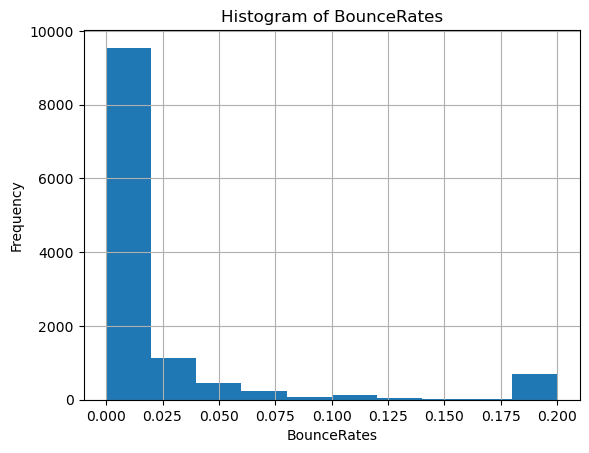

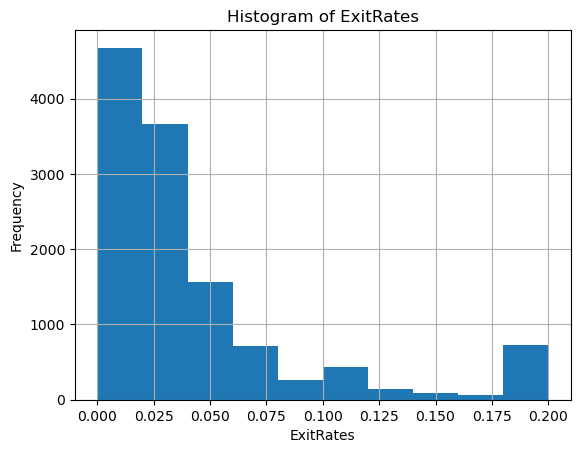

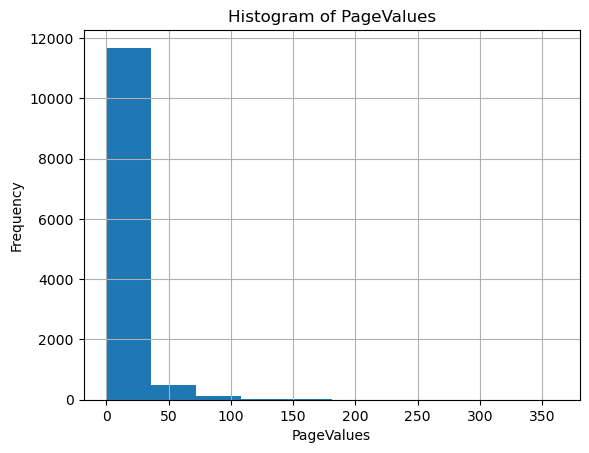

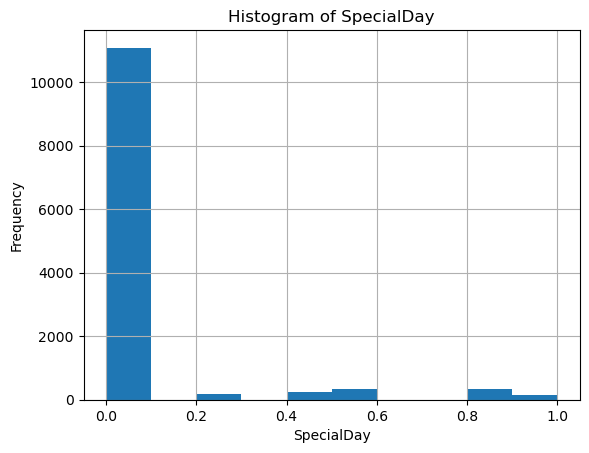

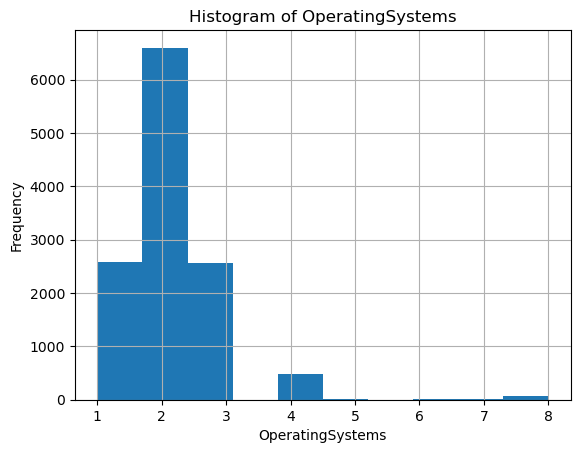

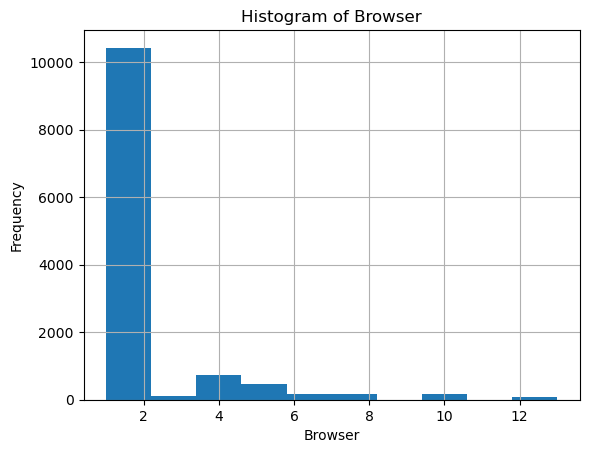

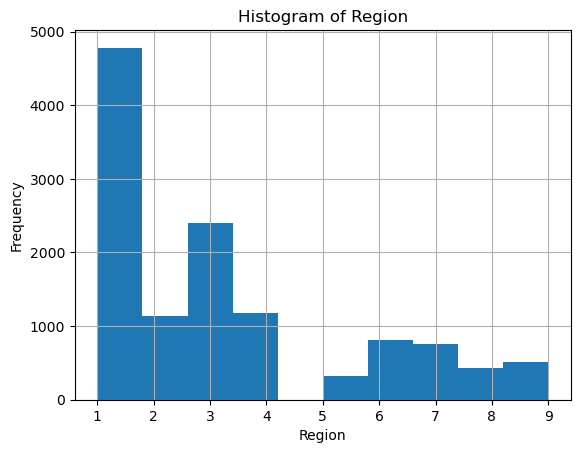

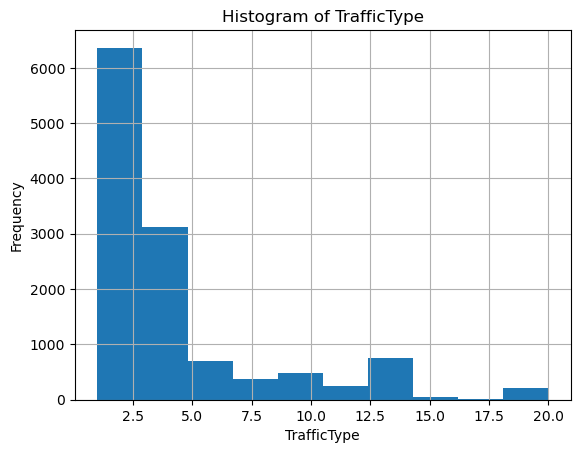

In [11]:
for c in df:
    if c in df.describe():
        plt.figure()
        df[c].hist()
        plt.title(f"Histogram of {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")

## Numerical Variables vs Revenue Bool

In the markdowns following the charts and groupby statements, i use median and mean in selective ways - where there are outliers for the max value of a variable, I use median, and I use either when there are no outliers, since the average wont be pulled by outlier values.

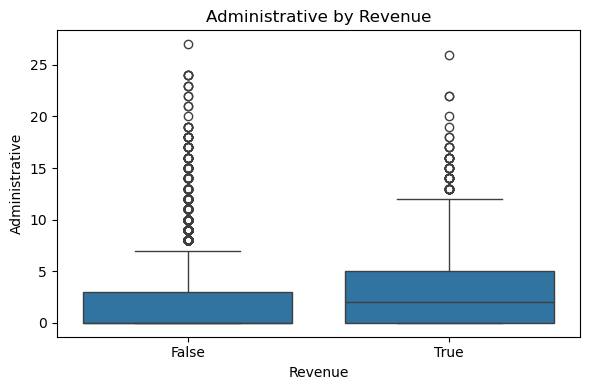

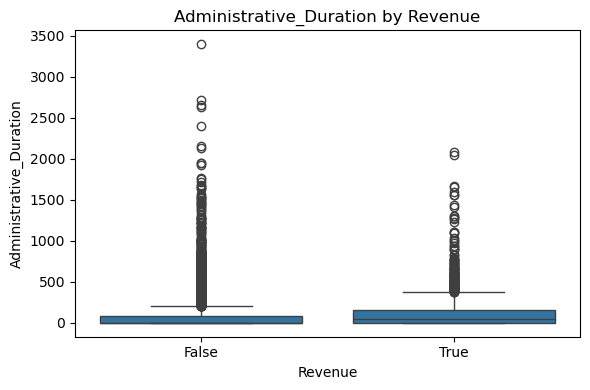

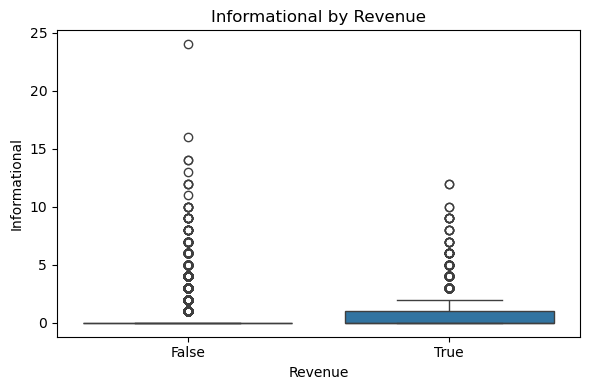

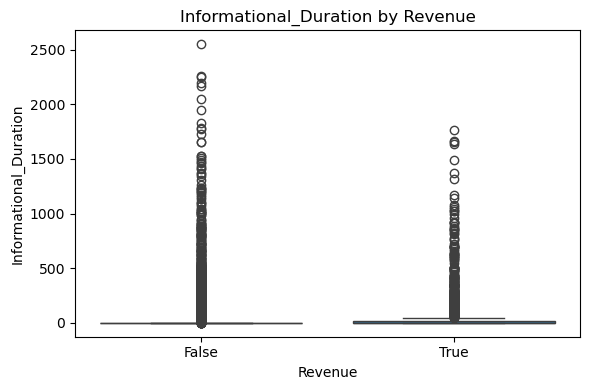

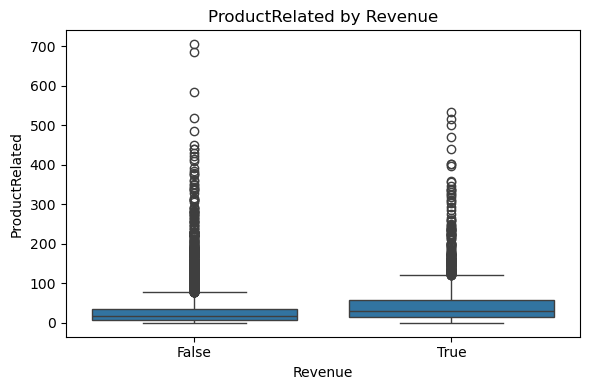

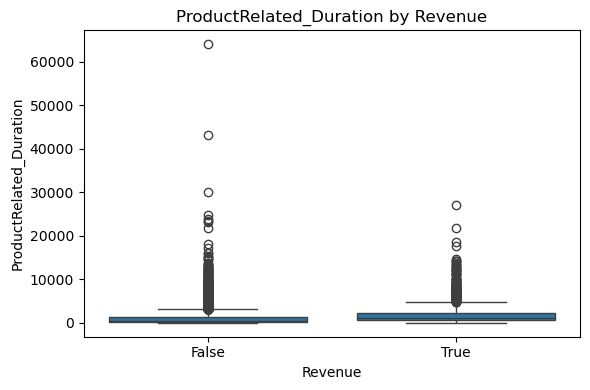

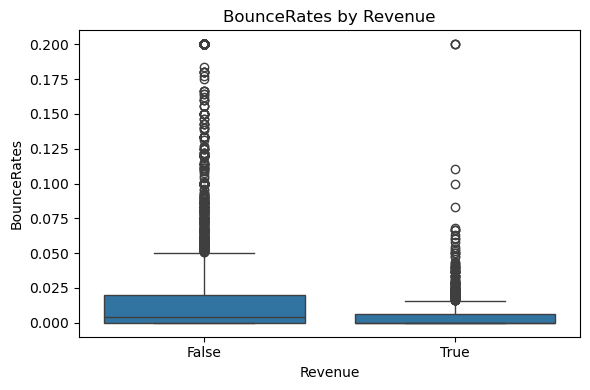

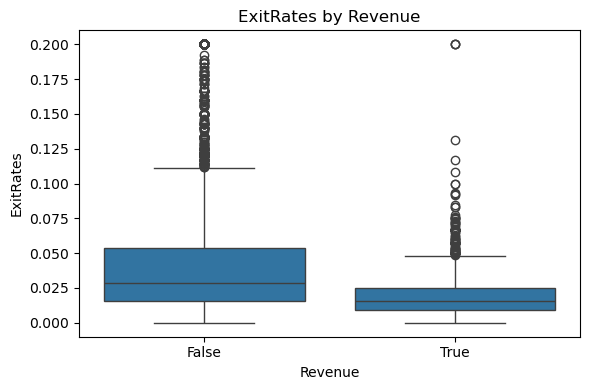

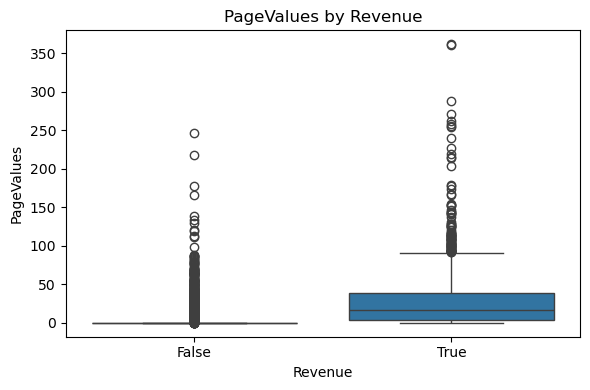

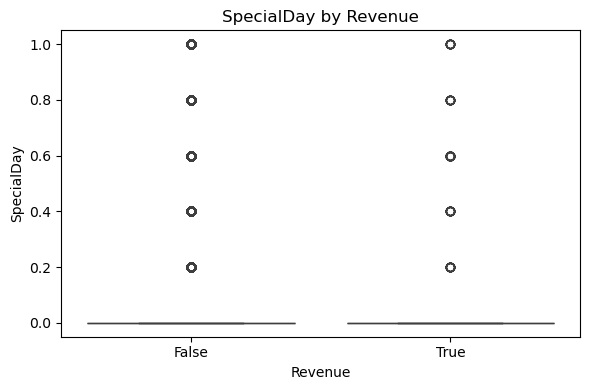

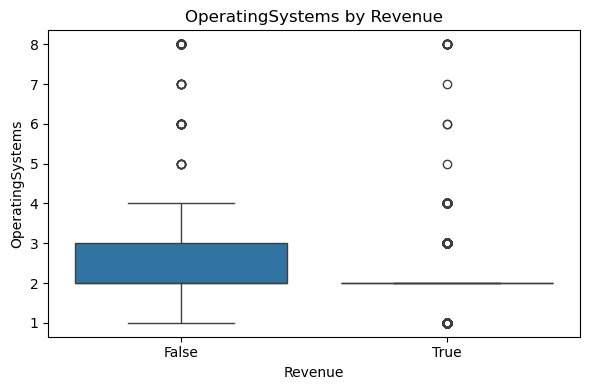

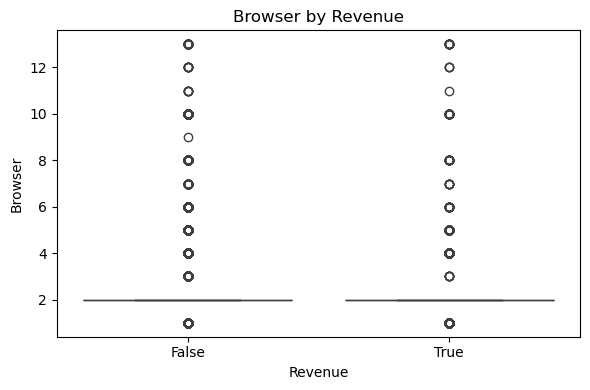

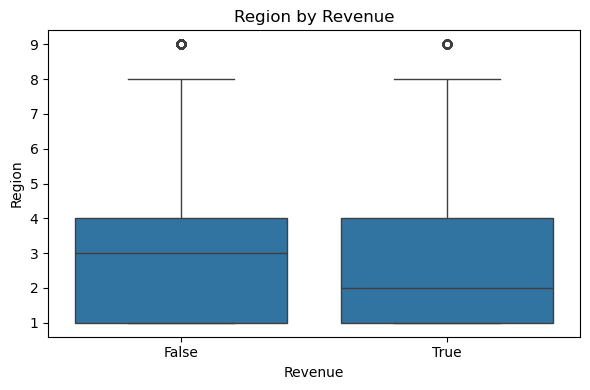

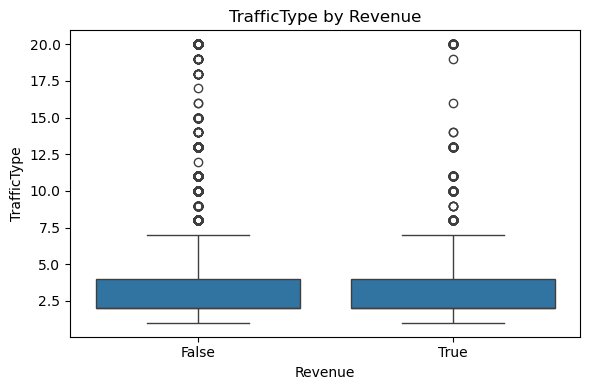

In [12]:
# Preliminary look at numerical variables against the desired outcome variable

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.title(f'{col} by Revenue')
    plt.xlabel('Revenue')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

The median number of pages visited for non-purchasers was around 0, while for purchasers it was around 2.5.
The duration for administrative page visits was also higher for purchasers.


In [13]:
df.groupby('Revenue')['Administrative'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,2.117732,3.202481,0.0,0.0,0.0,3.0,27.0
True,1908.0,3.393606,3.730527,0.0,0.0,2.0,5.0,26.0


For sessions that did end in a purchase, half of the users visited at least ~2 administrative pages, as opposed to 0 for non-purchase sessions.

In [14]:
df.groupby('Revenue')['Administrative_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,73.740111,171.017970,0.0,0.0,0.000000,83.000000,3398.75
True,1908.0,119.483244,201.114732,0.0,0.0,52.366667,151.083333,2086.75


Pick either Administrative pages or Administrative duration for the logistic regression model - do not use both as they're highly correlated.

Options: Ridge or Lasso regularization for automatic feature selection, or run VIF before and after dropping one of the variables.

Looking at the Informational vs Revenue graph, nearly no one aside from outlier cases, visited informational pages, except for when revenue was earned in a session - there was a percent of people who at least visited one. 

In [15]:
df.groupby('Revenue')['Informational'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.451833,1.211582,0.0,0.0,0.0,0.0,24.0
True,1908.0,0.786164,1.521176,0.0,0.0,0.0,1.0,12.0


25% of sessions with a purchase made had the user visit at least 1 informational page.

In [19]:
df.groupby('Revenue')['Informational_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,30.236237,133.909306,0.0,0.0,0.0,0.0,2549.375000
True,1908.0,57.611427,171.619131,0.0,0.0,0.0,19.0,1767.666667


Informational page visit duration was at 0 for nearly all sessions with no purchase, while at least 25% of sessions with a purchase spent 19 seconds on a page.

In [21]:
df.groupby('Revenue')['ProductRelated'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,28.714642,40.744717,0.0,6.0,16.0,35.0,705.0
True,1908.0,48.210168,58.267365,0.0,15.0,29.0,57.0,534.0


The number of product related pages visited in sessions with generated revenue had a median pages visited nearly nearly 2x higher than for sessions without revenue.

In [22]:
df.groupby('Revenue')['ProductRelated_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1069.987809,1803.797757,0.0,151.00000,510.19000,1331.816667,63973.52223
True,1908.0,1876.209615,2312.214392,0.0,541.90625,1109.90625,2266.011310,27009.85943


Product related page visit duration had a median visit take more than 2x longer for sessions with generated revenue.

In [23]:
df.groupby('Revenue')['BounceRates'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.025317,0.051877,0.0,0.0,0.004255,0.020000,0.2
True,1908.0,0.005117,0.012185,0.0,0.0,0.000000,0.006452,0.2


The average bounce rate is nearly 5x higher for sessions in which a purchase was not made.

In [24]:
df.groupby('Revenue')['ExitRates'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.047378,0.051231,0.0,0.015560,0.028571,0.053846,0.2
True,1908.0,0.019555,0.016463,0.0,0.009521,0.016000,0.025000,0.2


mean exit rates were more than 2x higher for sessions without generated revenue.

In [16]:
df.groupby('Revenue')['PageValues'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


That being said, there are significant differences in metrics- the median page value for sessions with a purchase is 16, compared to 0 for non-purchase sessions. At least 75% of revenue generating sessions had non-zero page values, while at least 75% of non revenue generating sessions had page values of exactly *zero*.

PageValues are derived from the revenue pages generate, so intuitively, pages that have high page values will likely lead to more generated revenue, which means they'll show up in our sessions with generated revenue more often. Page values will be a good predictive variable for the model.

Bounce rates seem to be some aggregation of values for the different pages visited during a session - with the type of aggregation being unknown (ie. average vs sum).

Informational pages show a very small p-value, meaning the visitation of informational pages during a session has a significant impact on a purchasing decision. This is a variable I'll use in a feature.

## Categorical Variables vs Revenue Bool

In [17]:
df['BounceRates'].value_counts()

BounceRates
0.000000    5518
0.200000     700
0.066667     134
0.028571     115
0.050000     113
            ... 
0.000866       1
0.005412       1
0.003828       1
0.000870       1
0.011149       1
Name: count, Length: 1872, dtype: int64

## Correlation Heat Map

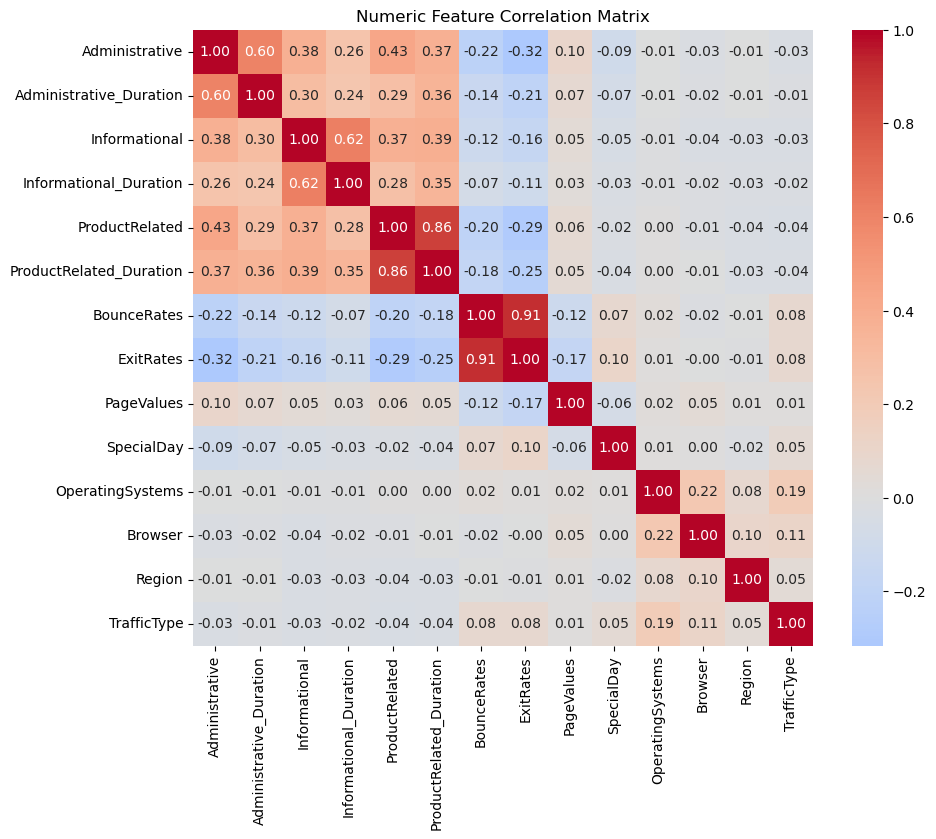

In [18]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr(method='pearson') 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation Matrix')
plt.show()